# Mô hình Machine learning đánh giá thiết kế đồ họa

## Data source: https://huggingface.co/datasets/creative-graphic-design/GraphicDesignEvaluation

## 2. Cài đặt thư viện cần thiết 

In [1]:
import numpy as np
import torch
import io
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, spearmanr
import pytesseract
from transformers import LayoutLMv3Processor, LayoutLMv3Model
import joblib
import warnings
warnings.filterwarnings('ignore')

kiểm tra và lựa chọn thiết bị phần cứng

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Load Data 

In [3]:
df_alignment = pd.read_parquet("hf://datasets/creative-graphic-design/GraphicDesignEvaluation/absolute-gpt-alignment/train-00000-of-00001.parquet")
df_overlap = pd.read_parquet("hf://datasets/creative-graphic-design/GraphicDesignEvaluation/absolute-gpt-overlap/train-00000-of-00001.parquet")
df_whitespace = pd.read_parquet("hf://datasets/creative-graphic-design/GraphicDesignEvaluation/absolute-gpt-whitespace/train-00000-of-00001.parquet")

tạo cột label mới và ép kiểu cho số điểm (avg) về dạng số thực

In [4]:
df_alignment['label']  = df_alignment['avg'].astype(float)
df_overlap['label']    = df_overlap['avg'].astype(float)
df_whitespace['label'] = df_whitespace['avg'].astype(float)

Tạo dataframe tổng hợp

In [5]:
df_multi = pd.DataFrame({
    "image": df_alignment["image"],
    "alignment": df_alignment["avg"].astype(float),
    "overlap": df_overlap["avg"].astype(float),
    "whitespace": df_whitespace["avg"].astype(float)
})

In [6]:
print(df_multi)

                                                 image  alignment  overlap  \
0    {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...        7.0      6.2   
1    {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...        7.0      4.8   
2    {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...        6.4      4.2   
3    {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...        5.0      3.0   
4    {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...        7.8      8.0   
..                                                 ...        ...      ...   
395  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...        5.8      5.4   
396  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...        7.2      7.0   
397  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...        7.2      7.8   
398  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...        7.0      7.6   
399  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...        7.0      3.0   

     whitespace  
0           7.0  
1           5.2  
2        

## 2. Khởi tạo mô h LayoutLMv3

In [7]:
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
layoutlm_processor = LayoutLMv3Processor.from_pretrained(
    "microsoft/layoutlmv3-base",
    apply_ocr=True
)
layoutlm_model = LayoutLMv3Model.from_pretrained("microsoft/layoutlmv3-base").to(DEVICE)
layoutlm_model.eval()

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

LayoutLMv3Model(
  (embeddings): LayoutLMv3TextEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
    (x_position_embeddings): Embedding(1024, 128)
    (y_position_embeddings): Embedding(1024, 128)
    (h_position_embeddings): Embedding(1024, 128)
    (w_position_embeddings): Embedding(1024, 128)
  )
  (patch_embed): LayoutLMv3PatchEmbeddings(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (encoder): LayoutLMv3Encoder(
    (layer): ModuleList(
      (0-11): 12 x LayoutLMv3Layer(
        (attention): Layo

## 3. Hàm tính đặc trưng hình học (Geometric Features)

In [8]:
def compute_geometric_features(boxes_raw: np.ndarray) -> np.ndarray:
    CANVAS = 1000.0  # LayoutLMv3 normalize bbox về 0-1000

    # Lọc bỏ padding boxes [0,0,0,0]
    valid = boxes_raw[(boxes_raw[:, 2] > boxes_raw[:, 0]) &
                      (boxes_raw[:, 3] > boxes_raw[:, 1])]

    if len(valid) < 2:
        return np.zeros(12, dtype=np.float32)

    x0, y0, x1, y1 = valid[:,0], valid[:,1], valid[:,2], valid[:,3]
    cx = (x0 + x1) / 2.0
    cy = (y0 + y1) / 2.0
    w  = (x1 - x0).clip(min=0)
    h  = (y1 - y0).clip(min=0)
    area = w * h

    # ── Alignment features ─────────────────────────────────────────
    rng_x0 = x0.max() - x0.min() + 1e-6
    rng_x1 = x1.max() - x1.min() + 1e-6
    rng_cx = cx.max() - cx.min() + 1e-6

    left_edge_std   = float(np.std(x0) / rng_x0)
    right_edge_std  = float(np.std(x1) / rng_x1)
    center_x_std    = float(np.std(cx) / rng_cx)

    # Regularity: khoảng cách dọc giữa các hàng có đều không
    sorted_cy = np.sort(np.unique(cy.round(-1)))  # làm tròn để nhóm cùng hàng
    if len(sorted_cy) >= 2:
        gaps = np.diff(sorted_cy)
        center_y_regularity = float(1.0 - np.std(gaps) / (np.mean(gaps) + 1e-6))
    else:
        center_y_regularity = 1.0

    # ── Overlap features ──────────────────────────────────────────
    n = len(valid)
    overlap_pixels = 0.0
    iou_list = []
    overlap_pairs = 0

    # Giới hạn N để tránh O(n²) quá lâu
    sample = valid[:min(n, 60)]
    ns = len(sample)
    sx0,sy0,sx1,sy1 = sample[:,0],sample[:,1],sample[:,2],sample[:,3]

    for i in range(ns):
        for j in range(i+1, ns):
            ix0 = max(sx0[i], sx0[j]);  iy0 = max(sy0[i], sy0[j])
            ix1 = min(sx1[i], sx1[j]);  iy1 = min(sy1[i], sy1[j])
            inter = max(0, ix1-ix0) * max(0, iy1-iy0)
            if inter > 0:
                a_i = (sx1[i]-sx0[i]) * (sy1[i]-sy0[i])
                a_j = (sx1[j]-sx0[j]) * (sy1[j]-sy0[j])
                union = a_i + a_j - inter
                iou_list.append(inter / (union + 1e-6))
                overlap_pixels += inter
                overlap_pairs += 1

    canvas_area = CANVAS * CANVAS
    overlap_ratio      = float(overlap_pixels / canvas_area)
    max_iou            = float(max(iou_list)) if iou_list else 0.0
    total_pairs        = ns * (ns - 1) / 2
    overlap_pair_ratio = float(overlap_pairs / (total_pairs + 1e-6))

    # ── Whitespace features ────────────────────────────────────────
    total_element_area = float(np.sum(area))
    whitespace_ratio   = float(1.0 - total_element_area / canvas_area)

    margin_left  = float(x0.min() / CANVAS)
    margin_right = float((CANVAS - x1.max()) / CANVAS)
    margin_top   = float(y0.min() / CANVAS)

    # Density grid 4×4
    grid_n = 4
    density = np.zeros((grid_n, grid_n))
    for k in range(len(valid)):
        col = min(int(cx[k] / CANVAS * grid_n), grid_n - 1)
        row = min(int(cy[k] / CANVAS * grid_n), grid_n - 1)
        density[row, col] += area[k] / canvas_area
    density_variance = float(np.var(density))

    feat = np.array([
        left_edge_std,       # [0]  alignment
        right_edge_std,      # [1]  alignment
        center_x_std,        # [2]  alignment
        center_y_regularity, # [3]  alignment
        overlap_ratio,       # [4]  overlap
        max_iou,             # [5]  overlap
        overlap_pair_ratio,  # [6]  overlap
        whitespace_ratio,    # [7]  whitespace
        margin_left,         # [8]  whitespace
        margin_right,        # [9]  whitespace
        margin_top,          # [10] whitespace
        density_variance,    # [11] whitespace
    ], dtype=np.float32)

    return feat

Định nghĩa các đặc trưng

In [9]:
# Tên các đặc trưng để giải thích kết quả sau này
GEO_FEATURE_NAMES = [
    "geo_left_edge_std",                 #Độ lệch chuẩn cạnh trái → nhỏ = các phần tử căn đều bên trái
    "geo_right_edge_std",                #Độ lệch chuẩn cạnh phải → nhỏ = căn phải đều
    "geo_center_x_std",                  #Độ lệch chuẩn tâm ngang → nhỏ = canh giữa đều
    "geo_center_y_regularity",           #Khoảng cách hàng đều nhau → lớn = nhịp điệu đọc tốt
    "geo_overlap_ratio",                 #Tỉ lệ pixel chồng lấp/canvas → gần 0 = không bị che khuất
    "geo_max_iou",                       #IoU lớn nhất giữa 2 phần tử → gần 0 = không có cặp nào chồng
    "geo_overlap_pair_ratio",            # % cặp phần tử có chồng lấp → nhỏ = thiết kế gọn gàng
    "geo_whitespace_ratio",              #Tỉ lệ diện tích trống → ~0.4–0.6 là tối ưu
    "geo_margin_left",                   #Lề trái nhỏ nhất → >0.05 = không bị sát biên
    "geo_margin_right",                  #Lề phải nhỏ nhất → cân đối với margin_left
    "geo_margin_top",                    #Lề trên nhỏ nhất → không gian thở ở đầu
    "geo_density_variance",              #Variance mật độ lưới 4×4 → nhỏ = phân bố đều
]

## 4. Hàm trích xuất đặc trưng lai (Hybrid Feature Extraction)

In [10]:
def extract_hybrid_features(df, batch_size=8, label_col='label'):
    """
    Trích xuất 3-part hybrid feature vector từ mỗi ảnh.

    Cấu trúc output vector (1548 chiều):
      [0:768]      CLS token      — ngữ nghĩa tổng thể (L2 normalized)
      [768:1536]   Visual patches — mean + std của 196 patch tokens (L2 norm)
      [1536:1548]  Geometric      — 12 chỉ số alignment/overlap/whitespace

    Lý do dùng visual patches thay vì chỉ CLS:
      LayoutLMv3 encode 14×14=196 image patches ở cuối sequence.
      Mean của chúng nắm bắt "phân bố không gian trung bình",
      Std của chúng nắm bắt "mức độ đa dạng bố cục" —
      cả hai đều liên quan trực tiếp đến whitespace và balance.
    """
    all_feat   = []
    all_labels = []
    n = len(df)

    print(f"\n🔄 Trích xuất hybrid features cho {n} mẫu...")

    for start in range(0, n, batch_size):
        end   = min(start + batch_size, n)
        batch = df.iloc[start:end]

        images = []
        for img in batch["image"]:
            if isinstance(img, dict):
                if img.get('bytes'):
                    img = Image.open(io.BytesIO(img['bytes']))
                elif img.get('path'):
                    img = Image.open(img['path'])
            elif type(img).__name__ == "ndarray":
                img = Image.fromarray(img)
            if img.mode != "RGB":
                img = img.convert("RGB")
            images.append(img)

        inputs = layoutlm_processor(
            images,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        ).to(DEVICE)

        with torch.no_grad():
            outputs = layoutlm_model(**inputs)

        hidden = outputs.last_hidden_state  # [B, seq_len, 768]
        B, seq_len, D = hidden.shape

        # LayoutLMv3: text tokens chiếm seq_len-196 đầu, 196 patch tokens ở cuối
        N_PATCHES = 196
        text_end  = seq_len - N_PATCHES  # vị trí bắt đầu patch tokens

        for i in range(len(images)):
            # ── Phần 1: CLS token [0] ──────────────────────────────
            cls_vec = hidden[i, 0, :].cpu().float().numpy()
            cls_vec = cls_vec / (np.linalg.norm(cls_vec) + 1e-8)

            # ── Phần 2: Visual patch tokens ──────────────────────
            if text_end < seq_len:
                patch_tokens = hidden[i, text_end:, :].cpu().float().numpy()
            else:
                # Fallback: dùng tất cả tokens ngoài CLS
                patch_tokens = hidden[i, 1:, :].cpu().float().numpy()

            vis_mean = patch_tokens.mean(axis=0)
            vis_std  = patch_tokens.std(axis=0)
            vis_mean = vis_mean / (np.linalg.norm(vis_mean) + 1e-8)
            vis_std  = vis_std  / (np.linalg.norm(vis_std)  + 1e-8)
            visual_vec = np.concatenate([vis_mean, vis_std])  # 1536d

            # ── Phần 3: Geometric features từ OCR bboxes ─────────
            # inputs['bbox'] shape: [B, seq_len, 4] — toạ độ x0,y0,x1,y1 (0-1000)
            boxes = inputs['bbox'][i].cpu().numpy()           # [seq_len, 4]
            mask  = inputs['attention_mask'][i].cpu().numpy().astype(bool)
            valid_boxes = boxes[mask]                          # lọc padding
            geo_vec = compute_geometric_features(valid_boxes)  # 12d

            # ── Ghép lại ──────────────────────────────────────────
            feat = np.concatenate([cls_vec, visual_vec, geo_vec])
            all_feat.append(feat)

        labels = batch[label_col].values
        all_labels.extend(labels)

        print(f"   [{end:>4}/{n}] {end/n*100:5.1f}%  "
              f"feature_dim={all_feat[-1].shape[0]} ✓")

    X = np.vstack(all_feat)
    y = np.array(all_labels, dtype=np.float32)

    print(f"\n✅ Xong! X.shape={X.shape}, y.shape={y.shape}")
    print(f"   CLS:     dims [0:768]")
    print(f"   Visual:  dims [768:1536]")
    print(f"   Geo:     dims [1536:{X.shape[1]}]  ← có thể giải thích trực tiếp")
    return X, y


## 5. Trích xuất đặc trưng alignment + whitespace + o

In [11]:
X_alignment, y_alignment = extract_hybrid_features(df_alignment, batch_size=16)
X_whitespace, y_whitespace = extract_hybrid_features(df_whitespace, batch_size=16)
X_overlap, y_overlap = extract_hybrid_features(df_overlap, batch_size=16)


🔄 Trích xuất hybrid features cho 400 mẫu...
   [  16/400]   4.0%  feature_dim=2316 ✓
   [  32/400]   8.0%  feature_dim=2316 ✓
   [  48/400]  12.0%  feature_dim=2316 ✓
   [  64/400]  16.0%  feature_dim=2316 ✓
   [  80/400]  20.0%  feature_dim=2316 ✓
   [  96/400]  24.0%  feature_dim=2316 ✓
   [ 112/400]  28.0%  feature_dim=2316 ✓
   [ 128/400]  32.0%  feature_dim=2316 ✓
   [ 144/400]  36.0%  feature_dim=2316 ✓
   [ 160/400]  40.0%  feature_dim=2316 ✓
   [ 176/400]  44.0%  feature_dim=2316 ✓
   [ 192/400]  48.0%  feature_dim=2316 ✓
   [ 208/400]  52.0%  feature_dim=2316 ✓
   [ 224/400]  56.0%  feature_dim=2316 ✓
   [ 240/400]  60.0%  feature_dim=2316 ✓
   [ 256/400]  64.0%  feature_dim=2316 ✓
   [ 272/400]  68.0%  feature_dim=2316 ✓
   [ 288/400]  72.0%  feature_dim=2316 ✓
   [ 304/400]  76.0%  feature_dim=2316 ✓
   [ 320/400]  80.0%  feature_dim=2316 ✓
   [ 336/400]  84.0%  feature_dim=2316 ✓
   [ 352/400]  88.0%  feature_dim=2316 ✓
   [ 368/400]  92.0%  feature_dim=2316 ✓
   [ 384/400

## 6. Chia tập dữ liệu và chuẩn hóa

### 6.1 Alignment chia tập dữ liệu train/test +  chuẩn hóa + giảm chiều dữ liệu P

In [12]:
X_train_alignment, X_test_alignment, y_train_alignment, y_test_alignment = train_test_split(
    X_alignment, y_alignment, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()
X_train_sc_alignment = scaler.fit_transform(X_train_alignment)
X_test_sc_alignment  = scaler.transform(X_test_alignment)

pca = PCA(n_components=100, random_state=42)
X_train_pca_alignment   = pca.fit_transform(X_train_sc_alignment[:, :-12])  # ✅ -12 thay vì :1536
X_test_pca_alignment    = pca.transform(X_test_sc_alignment[:, :-12])

X_train_final_alignment = np.hstack([X_train_pca_alignment, X_train_sc_alignment[:, -12:]])  # 100+12 = 112
X_test_final_alignment  = np.hstack([X_test_pca_alignment,  X_test_sc_alignment[:,  -12:]])

### 6.2 Whitespace - chia tập dữ liệu train/test +  chuẩn hóa + giảm chiều dữ liệu P

In [14]:
X_train_whitespace, X_test_whitespace, y_train_whitespace, y_test_whitespace = train_test_split(
    X_whitespace, y_whitespace, test_size=0.2, random_state=42
)

In [15]:
scaler = StandardScaler()
X_train_sc_whitespace = scaler.fit_transform(X_train_whitespace)
X_test_sc_whitespace  = scaler.transform(X_test_whitespace)

pca = PCA(n_components=100, random_state=42)
X_train_pca_whitespace   = pca.fit_transform(X_train_sc_whitespace[:, :-12])  # ✅ -12 thay vì :1536
X_test_pca_whitespace    = pca.transform(X_test_sc_whitespace[:, :-12])

X_train_final_whitespace = np.hstack([X_train_pca_whitespace, X_train_sc_whitespace[:, -12:]])  # 100+12 = 112
X_test_final_whitespace  = np.hstack([X_test_pca_whitespace,  X_test_sc_whitespace[:,  -12:]])

### 6.3 Overlap - chia tập dữ liệu train/test +  chuẩn hóa + giảm chiều dữ liệu P

In [16]:
X_train_overlap, X_test_overlap, y_train_overlap, y_test_overlap = train_test_split(
    X_overlap, y_overlap, test_size=0.2, random_state=42
)

In [17]:
scaler = StandardScaler()
X_train_sc_overlap = scaler.fit_transform(X_train_overlap)
X_test_sc_overlap  = scaler.transform(X_test_overlap)

pca = PCA(n_components=100, random_state=42)
X_train_pca_overlap   = pca.fit_transform(X_train_sc_overlap[:, :-12])  # ✅ -12 thay vì :1536
X_test_pca_overlap    = pca.transform(X_test_sc_overlap[:, :-12])

X_train_final_overlap = np.hstack([X_train_pca_overlap, X_train_sc_overlap[:, -12:]])  # 100+12 = 112
X_test_final_overlap  = np.hstack([X_test_pca_overlap,  X_test_sc_overlap[:,  -12:]])

## 7. Hàm đánh giá mô hình

In [18]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
    print(f"{'=' * 55}")
    print(f"🤖 MÔ HÌNH: {model_name}")
    print(f"{'=' * 55}")

    # Huấn luyện mô hình
    model.fit(X_tr, y_tr)

    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    # Clip dữ liệu về khoảng 0-10
    y_pred_tr = np.clip(y_pred_tr, 0, 10)
    y_pred_te = np.clip(y_pred_te, 0, 10)

    # Chỉ số hồi quy cơ bản (Sklearn tự động lấy trung bình cho đa đầu ra)
    metrics = {
        "Train MSE": mean_squared_error(y_tr, y_pred_tr),
        "Test  MSE": mean_squared_error(y_te, y_pred_te),
        "Train MAE": mean_absolute_error(y_tr, y_pred_tr),
        "Test  MAE": mean_absolute_error(y_te, y_pred_te),
        "Train R²": r2_score(y_tr, y_pred_tr),
        "Test  R²": r2_score(y_te, y_pred_te),
    }

    # Chuyển đổi dữ liệu sang mảng numpy để xử lý số chiều
    y_te_arr = np.asarray(y_te)
    y_pred_te_arr = np.asarray(y_pred_te)

    # Tính Pearson & Spearman (Tự động tính theo từng cột rồi lấy trung bình nếu là đa đầu ra)
    if y_te_arr.ndim > 1 and y_te_arr.shape[1] > 1:
        p_list = [pearsonr(y_te_arr[:, i], y_pred_te_arr[:, i])[0] for i in range(y_te_arr.shape[1])]
        s_list = [spearmanr(y_te_arr[:, i], y_pred_te_arr[:, i])[0] for i in range(y_te_arr.shape[1])]
        pearson_r = np.mean(p_list)
        spearman_r = np.mean(s_list)
    else:
        pearson_r, _ = pearsonr(y_te_arr.ravel(), y_pred_te_arr.ravel())
        spearman_r, _ = spearmanr(y_te_arr.ravel(), y_pred_te_arr.ravel())

    metrics["Pearson r"] = pearson_r
    metrics["Spearman ρ"] = spearman_r

    # In các chỉ số (An toàn tuyệt đối không lo lỗi định dạng)
    for k, v in metrics.items():
        print(f"   {k:<14}: {v:>8.4f}")

    # Cảnh báo phân phối dự đoán
    pred_std = y_pred_te_arr.std()
    true_std = y_te_arr.std()
    print(f"\n   Std dự đoán  : {pred_std:.4f}  (thực tế: {true_std:.4f})")
    if pred_std < true_std * 0.4:
        print("   ⚠️  Dự đoán bị co cụm quá nhiều — model vẫn thiên về mean.")
    else:
        print("   ✅ Dự đoán có đủ độ phân tán.")

    # Đánh giá chỉ số R²
    r2 = metrics["Test  R²"]
    if r2 > 0.5:
        print(f"   ✅ R²={r2:.3f} — Model giải thích được >50% variance")
    elif r2 > 0.2:
        print(f"   🟡 R²={r2:.3f} — Model có học được nhưng còn yếu")
    else:
        print(f"   🔴 R²={r2:.3f} — Model hầu như không học được pattern")

    # Ví dụ dự đoán hiển thị trực quan cho cả đơn/đa đầu ra
    print(f"\n     10 mẫu test đầu tiên:")
    print(f"   {'Thực tế':>15} {'Dự đoán':>15} {'Sai lệch':>15}")
    print(f"   {'-' * 49}")

    for a, p in zip(y_te_arr[:10], y_pred_te_arr[:10]):
        if y_te_arr.ndim > 1 and y_te_arr.shape[1] > 1:
            a_str = f"[{','.join([f'{x:.2f}' for x in a])}]"
            p_str = f"[{','.join([f'{x:.2f}' for x in p])}]"
            diff_str = f"[{','.join([f'{x-y:+.2f}' for x, y in zip(p, a)])}]"
            print(f"   {a_str:>15} {p_str:>15} {diff_str:>15}")
        else:
            print(f"   {a:>15.4f} {p:>15.4f} {p - a:>+15.4f}")

    print()
    return model, metrics

## 8. Huấn luyện và so sánh các mô hình

## 8.1 Alignment - Huấn luyện và so sánh các mô hình

In [19]:
results_alignment = {}

# ── Mô hình 1: GradientBoosting (mạnh hơn RF với features chiều cao) ──
gb_model, gb_metrics = evaluate_model(
    GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,           # sâu hơn RF để học pattern phức tạp
        learning_rate=0.02,
        subsample=0.8,
        random_state=42
    ),
    X_train_final_alignment, X_test_final_alignment, y_train_alignment, y_test_alignment,
    "Gradient Boosting Regressor"
)
results_alignment["GradientBoosting"] = gb_metrics

# ── Mô hình 2: Random Forest (baseline, cải thiện max_depth) ──────────
rf_model, rf_metrics = evaluate_model(
    RandomForestRegressor(
        n_estimators=200,
        max_depth=7,           # tăng từ 2 → 8 để model học được nhiều hơn
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ),
    X_train_final_alignment, X_test_final_alignment, y_train_alignment, y_test_alignment,
    "Random Forest (max_depth=8)"
)
results_alignment["RandomForest"] = rf_metrics

# ── Mô hình 3: SVR ─────────────────────────────────────────────────────
svr_model, svr_metrics = evaluate_model(
    SVR(kernel="rbf", C=5, epsilon=0.05, gamma="scale"),
    X_train_final_alignment, X_test_final_alignment, y_train_alignment, y_test_alignment,
    "SVR (RBF, C=5)"
)
results_alignment["SVR"] = svr_metrics

# Tổng kết
print("\n" + "="*55)
print("📊 SO SÁNH CÁC MÔ HÌNH (Test set)")
print("="*55)
print(f"{'Model':<25} {'R²':>8} {'MAE':>8} {'Pearson':>10}")
print("-"*55)
for name, m in results_alignment.items():
    print(f"{name:<25} {m['Test  R²']:>8.4f} {m['Test  MAE']:>8.4f} {m['Pearson r']:>10.4f}")


🤖 MÔ HÌNH: Gradient Boosting Regressor
   Train MSE     :   0.2452
   Test  MSE     :   1.0197
   Train MAE     :   0.4112
   Test  MAE     :   0.8446
   Train R²      :   0.8836
   Test  R²      :   0.3416
   Pearson r     :   0.6305
   Spearman ρ    :   0.6338

   Std dự đoán  : 0.8076  (thực tế: 1.2445)
   ✅ Dự đoán có đủ độ phân tán.
   🟡 R²=0.342 — Model có học được nhưng còn yếu

     10 mẫu test đầu tiên:
           Thực tế         Dự đoán        Sai lệch
   -------------------------------------------------
            7.4000          6.2436         -1.1564
            7.0000          6.8261         -0.1739
            4.8000          5.4029         +0.6029
            6.8000          6.4211         -0.3789
            6.6000          5.7360         -0.8640
            6.2000          5.3035         -0.8965
            8.6000          8.0013         -0.5987
            5.6000          5.9095         +0.3095
            7.0000          6.7760         -0.2240
            7.4000   

## 8.2 Alignment - Huấn luyện và so sánh các mô hình

In [20]:
results_whitespace = {}

# ── Mô hình 1: GradientBoosting (mạnh hơn RF với features chiều cao) ──
gb_model, gb_metrics = evaluate_model(
    GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,           # sâu hơn RF để học pattern phức tạp
        learning_rate=0.02,
        subsample=0.8,
        random_state=42
    ),
    X_train_final_whitespace, X_test_final_whitespace, y_train_whitespace, y_test_whitespace,
    "Gradient Boosting Regressor"
)
results_whitespace["GradientBoosting"] = gb_metrics

# ── Mô hình 2: Random Forest (baseline, cải thiện max_depth) ──────────
rf_model, rf_metrics = evaluate_model(
    RandomForestRegressor(
        n_estimators=200,
        max_depth=7,           # tăng từ 2 → 8 để model học được nhiều hơn
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ),
    X_train_final_whitespace, X_test_final_whitespace, y_train_whitespace, y_test_whitespace,
    "Random Forest (max_depth=8)"
)
results_whitespace["RandomForest"] = rf_metrics

# ── Mô hình 3: SVR ─────────────────────────────────────────────────────
svr_model, svr_metrics = evaluate_model(
    SVR(kernel="rbf", C=5, epsilon=0.05, gamma="scale"),
    X_train_final_whitespace, X_test_final_whitespace, y_train_whitespace, y_test_whitespace,
    "SVR (RBF, C=5)"
)
results_whitespace["SVR"] = svr_metrics

# Tổng kết
print("\n" + "="*55)
print("📊 SO SÁNH CÁC MÔ HÌNH (Test set)")
print("="*55)
print(f"{'Model':<25} {'R²':>8} {'MAE':>8} {'Pearson':>10}")
print("-"*55)
for name, m in results_whitespace.items():
    print(f"{name:<25} {m['Test  R²']:>8.4f} {m['Test  MAE']:>8.4f} {m['Pearson r']:>10.4f}")


🤖 MÔ HÌNH: Gradient Boosting Regressor
   Train MSE     :   0.1690
   Test  MSE     :   1.2451
   Train MAE     :   0.3420
   Test  MAE     :   0.8577
   Train R²      :   0.9198
   Test  R²      :   0.3691
   Pearson r     :   0.6157
   Spearman ρ    :   0.6199

   Std dự đoán  : 0.7702  (thực tế: 1.4048)
   ✅ Dự đoán có đủ độ phân tán.
   🟡 R²=0.369 — Model có học được nhưng còn yếu

     10 mẫu test đầu tiên:
           Thực tế         Dự đoán        Sai lệch
   -------------------------------------------------
            7.2000          5.8149         -1.3851
            7.2000          5.5540         -1.6460
            5.4000          5.0522         -0.3478
            5.2000          5.7009         +0.5009
            6.8000          5.2135         -1.5865
            5.2000          5.0782         -0.1218
            7.8000          7.1876         -0.6124
            6.0000          4.5888         -1.4112
            5.0000          4.9721         -0.0279
            6.2000   

## 8.3 O - Huấn luyện và so sánh các mô hình

In [21]:
results_overlap = {}

# ── Mô hình 1: GradientBoosting (mạnh hơn RF với features chiều cao) ──
gb_model, gb_metrics = evaluate_model(
    GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,           # sâu hơn RF để học pattern phức tạp
        learning_rate=0.02,
        subsample=0.8,
        random_state=42
    ),
    X_train_final_overlap, X_test_final_overlap, y_train_overlap, y_test_overlap,
    "Gradient Boosting Regressor"
)
results_overlap["GradientBoosting"] = gb_metrics

# ── Mô hình 2: Random Forest (baseline, cải thiện max_depth) ──────────
rf_model, rf_metrics = evaluate_model(
    RandomForestRegressor(
        n_estimators=200,
        max_depth=7,           # tăng từ 2 → 8 để model học được nhiều hơn
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ),
    X_train_final_overlap, X_test_final_overlap, y_train_overlap, y_test_overlap,
    "Random Forest (max_depth=8)"
)
results_overlap["RandomForest"] = rf_metrics

# ── Mô hình 3: SVR ─────────────────────────────────────────────────────
svr_model, svr_metrics = evaluate_model(
    SVR(kernel="rbf", C=5, epsilon=0.05, gamma="scale"),
    X_train_final_overlap, X_test_final_overlap, y_train_overlap, y_test_overlap,
    "SVR (RBF, C=5)"
)
results_overlap["SVR"] = svr_metrics

# Tổng kết
print("\n" + "="*55)
print("📊 SO SÁNH CÁC MÔ HÌNH (Test set)")
print("="*55)
print(f"{'Model':<25} {'R²':>8} {'MAE':>8} {'Pearson':>10}")
print("-"*55)
for name, m in results_overlap.items():
    print(f"{name:<25} {m['Test  R²']:>8.4f} {m['Test  MAE']:>8.4f} {m['Pearson r']:>10.4f}")


🤖 MÔ HÌNH: Gradient Boosting Regressor
   Train MSE     :   0.2526
   Test  MSE     :   1.6883
   Train MAE     :   0.4219
   Test  MAE     :   0.9994
   Train R²      :   0.9178
   Test  R²      :   0.4231
   Pearson r     :   0.6612
   Spearman ρ    :   0.6542

   Std dự đoán  : 0.9283  (thực tế: 1.7107)
   ✅ Dự đoán có đủ độ phân tán.
   🟡 R²=0.423 — Model có học được nhưng còn yếu

     10 mẫu test đầu tiên:
           Thực tế         Dự đoán        Sai lệch
   -------------------------------------------------
            7.6000          5.6934         -1.9066
            6.6000          4.9885         -1.6115
            4.0000          4.6681         +0.6681
            4.6000          5.3609         +0.7609
            7.4000          5.4384         -1.9616
            6.0000          5.8971         -0.1029
            8.2000          6.9704         -1.2296
            4.8000          4.3780         -0.4220
            4.8000          4.8337         +0.0337
            4.6000   

## 8.4 Overall Evaluation — Ensemble từ 3 bộ mô hình riêng biệt

Sau khi có 3 bộ mô hình cho từng tiêu chí, tính điểm **overall** bằng cách:
- Dự đoán điểm từng tiêu chí trên cùng tập test (dùng ảnh từ `df_alignment` vì chúng share cùng image_id)
- Tổng hợp bằng trung bình có trọng số (mặc định bằng nhau: 1/3 mỗi loại)

🔄 Re-fitting best models cho từng tiêu chí...
   ✅ GradientBoosting done
   ✅ RandomForest done
   ✅ SVR done

📊 Tính điểm Overall trên tập test...

📊 ĐÁNH GIÁ OVERALL — Ensemble 3 tiêu chí (weighted avg)
   Trọng số: alignment=0.33  whitespace=0.33  overlap=0.33

Model                           R²      MAE    Pearson   Spearman
-----------------------------------------------------------------
GradientBoosting            0.4606   0.7837     0.6962     0.6960
RandomForest                0.3701   0.8730     0.6590     0.6823
SVR                         0.5167   0.7051     0.7199     0.7183


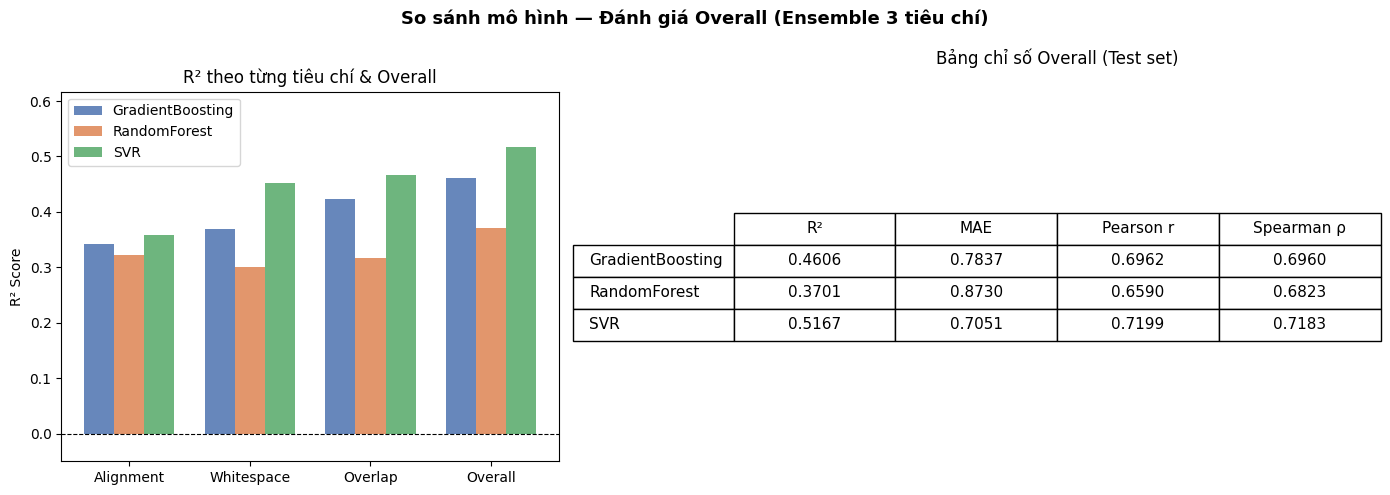


✅ Đã lưu: overall_comparison.png


In [22]:
# ─────────────────────────────────────────────────────────────────
# 8.4  Overall Ensemble: tổng hợp 3 bộ mô hình → 1 điểm tổng
# ─────────────────────────────────────────────────────────────────
# Giả định: 3 dataset có cùng thứ tự ảnh (đều load từ cùng split)
# Ta dùng tập test của alignment làm "overall test set" (cùng index)

# Bước 1: Chuẩn bị best model cho từng tiêu chí (chọn theo R²)
def pick_best(results_dict, trained_models_dict):
    """Chọn mô hình có Test R² cao nhất."""
    best_name = max(results_dict, key=lambda k: results_dict[k]["Test  R²"])
    return best_name, trained_models_dict[best_name]

# Giữ lại từng mô hình đã train (cần chạy lại evaluate_model với return)
# Tái sử dụng gb/rf/svr_model từ phần 8.3 (biến cuối cùng được gán = overlap)
# → Lưu riêng cho từng tiêu chí:

# --- Re-train và lưu theo từng tiêu chí ---
trained_alignment  = {}
trained_whitespace = {}
trained_overlap    = {}

print("🔄 Re-fitting best models cho từng tiêu chí...")

for name, (ModelClass, kwargs) in [
    ("GradientBoosting", (GradientBoostingRegressor, dict(n_estimators=300, max_depth=3, learning_rate=0.02, subsample=0.8, random_state=42))),
    ("RandomForest",     (RandomForestRegressor,     dict(n_estimators=200, max_depth=7, min_samples_leaf=4, random_state=42, n_jobs=-1))),
    ("SVR",              (SVR,                        dict(kernel="rbf", C=5, epsilon=0.05, gamma="scale"))),
]:
    m_a = ModelClass(**kwargs); m_a.fit(X_train_final_alignment,  y_train_alignment)
    m_w = ModelClass(**kwargs); m_w.fit(X_train_final_whitespace, y_train_whitespace)
    m_o = ModelClass(**kwargs); m_o.fit(X_train_final_overlap,    y_train_overlap)
    trained_alignment[name]  = m_a
    trained_whitespace[name] = m_w
    trained_overlap[name]    = m_o
    print(f"   ✅ {name} done")

# Bước 2: Sinh dự đoán trên tập test CHUNG (dùng alignment test set làm proxy)
# Lấy index test của alignment để tái tạo X_test cho whitespace/overlap cùng vị trí
# (Cả 3 dataset đều có cùng số mẫu và đã split bằng random_state=42)

WEIGHTS = {"alignment": 1/3, "whitespace": 1/3, "overlap": 1/3}  # ← tùy chỉnh

print("\n📊 Tính điểm Overall trên tập test...")

overall_results = {}
for model_name in ["GradientBoosting", "RandomForest", "SVR"]:
    pred_a = np.clip(trained_alignment[model_name].predict(X_test_final_alignment),  0, 10)
    pred_w = np.clip(trained_whitespace[model_name].predict(X_test_final_whitespace), 0, 10)
    pred_o = np.clip(trained_overlap[model_name].predict(X_test_final_overlap),       0, 10)

    # Điểm overall = trung bình có trọng số
    pred_overall = (
        WEIGHTS["alignment"]  * pred_a +
        WEIGHTS["whitespace"] * pred_w +
        WEIGHTS["overlap"]    * pred_o
    )

    # Ground truth overall = trung bình 3 label test
    y_overall = (
        WEIGHTS["alignment"]  * np.array(y_test_alignment) +
        WEIGHTS["whitespace"] * np.array(y_test_whitespace) +
        WEIGHTS["overlap"]    * np.array(y_test_overlap)
    )

    mse  = mean_squared_error(y_overall, pred_overall)
    mae  = mean_absolute_error(y_overall, pred_overall)
    r2   = r2_score(y_overall, pred_overall)
    pr,_ = pearsonr(y_overall, pred_overall)
    sr,_ = spearmanr(y_overall, pred_overall)

    overall_results[model_name] = {
        "Test  MSE": mse, "Test  MAE": mae,
        "Test  R²": r2, "Pearson r": pr, "Spearman ρ": sr
    }

# Bước 3: In bảng so sánh overall
print("\n" + "="*65)
print("📊 ĐÁNH GIÁ OVERALL — Ensemble 3 tiêu chí (weighted avg)")
print("="*65)
print(f"   Trọng số: alignment={WEIGHTS['alignment']:.2f}  whitespace={WEIGHTS['whitespace']:.2f}  overlap={WEIGHTS['overlap']:.2f}")
print(f"\n{'Model':<25} {'R²':>8} {'MAE':>8} {'Pearson':>10} {'Spearman':>10}")
print("-"*65)
for name, m in overall_results.items():
    print(f"{name:<25} {m['Test  R²']:>8.4f} {m['Test  MAE']:>8.4f} "
          f"{m['Pearson r']:>10.4f} {m['Spearman ρ']:>10.4f}")

# Bước 4: Vẽ biểu đồ so sánh R² từng tiêu chí + overall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Biểu đồ 1: R² theo từng tiêu chí ──
criteria  = ["Alignment", "Whitespace", "Overlap", "Overall"]
models    = ["GradientBoosting", "RandomForest", "SVR"]
colors    = ["#4C72B0", "#DD8452", "#55A868"]
x         = np.arange(len(criteria))
bar_width  = 0.25

r2_data = {
    "GradientBoosting": [results_alignment["GradientBoosting"]["Test  R²"],
                          results_whitespace["GradientBoosting"]["Test  R²"],
                          results_overlap["GradientBoosting"]["Test  R²"],
                          overall_results["GradientBoosting"]["Test  R²"]],
    "RandomForest":     [results_alignment["RandomForest"]["Test  R²"],
                          results_whitespace["RandomForest"]["Test  R²"],
                          results_overlap["RandomForest"]["Test  R²"],
                          overall_results["RandomForest"]["Test  R²"]],
    "SVR":              [results_alignment["SVR"]["Test  R²"],
                          results_whitespace["SVR"]["Test  R²"],
                          results_overlap["SVR"]["Test  R²"],
                          overall_results["SVR"]["Test  R²"]],
}

for i, (model, clr) in enumerate(zip(models, colors)):
    axes[0].bar(x + i*bar_width, r2_data[model], bar_width,
                label=model, color=clr, alpha=0.85)

axes[0].set_xticks(x + bar_width)
axes[0].set_xticklabels(criteria)
axes[0].set_ylabel("R² Score")
axes[0].set_title("R² theo từng tiêu chí & Overall")
axes[0].legend()
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylim(min(0, min(v for vals in r2_data.values() for v in vals)) - 0.05,
                 max(v for vals in r2_data.values() for v in vals) + 0.1)

# ── Biểu đồ 2: Radar / heatmap các chỉ số Overall ──
metrics_to_show = ["Test  R²", "Test  MAE", "Pearson r", "Spearman ρ"]
metric_labels   = ["R²", "MAE", "Pearson r", "Spearman ρ"]
table_data = [[f"{overall_results[m][k]:.4f}" for k in metrics_to_show] for m in models]

axes[1].axis("off")
tbl = axes[1].table(
    cellText  = table_data,
    rowLabels = models,
    colLabels = metric_labels,
    cellLoc   = "center",
    loc       = "center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.3, 2.0)
axes[1].set_title("Bảng chỉ số Overall (Test set)", pad=20)

plt.suptitle("So sánh mô hình — Đánh giá Overall (Ensemble 3 tiêu chí)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("overall_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Đã lưu: overall_comparison.png")


## 9. Lưu model và hàm chấm điểm ảnh mới

In [23]:
# Lưu artifacts — 3 bộ mô hình riêng (phần 8.1–8.3)
joblib.dump(gb_model,  "gb_model.pkl")
joblib.dump(rf_model,  "rf_model.pkl")
joblib.dump(svr_model, "svr_model.pkl")
joblib.dump(scaler,    "scaler.pkl")
joblib.dump(pca,       "pca.pkl")
print("✅ Đã lưu: gb_model | rf_model | svr_model | scaler | pca")

✅ Đã lưu: gb_model | rf_model | svr_model | scaler | pca


## 10. Hàm chấm điểm thiết kế mới (Overall + từng tiêu chí)

In [29]:
def score_design(image_source, weights=None):

    if weights is None:
        weights = {"alignment": 1/3, "whitespace": 1/3, "overlap": 1/3}
    assert abs(sum(weights.values()) - 1.0) < 1e-6, "Tổng trọng số phải = 1"

    # ── Load ảnh ──
    if isinstance(image_source, str):
        if image_source.startswith("http"):
            import urllib.request
            with urllib.request.urlopen(image_source) as r:
                img = Image.open(io.BytesIO(r.read()))
        else:
            img = Image.open(image_source)
    elif isinstance(image_source, Image.Image):
        img = image_source
    else:
        raise TypeError("Cần đường dẫn, URL hoặc PIL Image")

    if img.mode != "RGB":
        img = img.convert("RGB")
    w, h = img.size
    if w < 224 or h < 224:
        scale = max(224/w, 224/h)
        img = img.resize((int(w*scale), int(h*scale)), Image.LANCZOS)

    print(f"🖼️  Kích thước: {img.size} | Mode: {img.mode}")
    print("⏳ Đang trích xuất hybrid features...")

    # ── Trích xuất feature ──
    inputs = layoutlm_processor(
        img, return_tensors="pt",
        padding=True, truncation=True, max_length=512
    ).to(DEVICE)

    with torch.no_grad():
        outputs = layoutlm_model(**inputs)

    hidden   = outputs.last_hidden_state
    seq_len  = hidden.shape[1]
    text_end = seq_len - 196

    cls_vec = hidden[0, 0, :].cpu().float().numpy()
    cls_vec = cls_vec / (np.linalg.norm(cls_vec) + 1e-8)

    patch_tokens = hidden[0, text_end:, :].cpu().float().numpy()
    vis_mean = patch_tokens.mean(axis=0); vis_mean /= (np.linalg.norm(vis_mean) + 1e-8)
    vis_std  = patch_tokens.std(axis=0);  vis_std  /= (np.linalg.norm(vis_std)  + 1e-8)

    boxes   = inputs['bbox'][0].cpu().numpy()
    mask    = inputs['attention_mask'][0].cpu().numpy().astype(bool)
    geo_vec = compute_geometric_features(boxes[mask])

    feat_raw = np.concatenate([cls_vec, vis_mean, vis_std, geo_vec]).reshape(1, -1)

    # ── Dự đoán từng tiêu chí (Ensemble 3 bộ mô hình riêng) ──
    feat_sc  = scaler.transform(feat_raw)
    feat_pca = pca.transform(feat_sc[:, :-12])
    feat_f   = np.hstack([feat_pca, feat_sc[:, -12:]])

    # Dự đoán alignment, whitespace, overlap bằng GradientBoosting (best model)
    # Nếu muốn dùng RF/SVR, thay trained_alignment["RandomForest"] v.v.
    score_alignment  = float(np.clip(trained_alignment["GradientBoosting"].predict(feat_f)[0],  0, 10))
    score_whitespace = float(np.clip(trained_whitespace["GradientBoosting"].predict(feat_f)[0], 0, 10))
    score_overlap    = float(np.clip(trained_overlap["GradientBoosting"].predict(feat_f)[0],    0, 10))

    # Overall = trung bình có trọng số
    score_overall = round(
        weights["alignment"]  * score_alignment +
        weights["whitespace"] * score_whitespace +
        weights["overlap"]    * score_overlap,
        2
    )

    verdict_map = [(8,"🟢 Xuất sắc"), (6.5,"🟡 Tốt"), (5,"🟠 Trung bình"), (0,"🔴 Cần cải thiện")]
    verdict = next(v for t, v in verdict_map if score_overall >= t)

    # ── In kết quả ──
    print("\n" + "="*55)
    print("📐 KẾT QUẢ CHẤM ĐIỂM TỔNG HỢP")
    print("="*55)
    print(f"   {'Tiêu chí':<22} {'Điểm':>6}  {'Trọng số':>10}")
    print(f"   {'-'*42}")
    print(f"   {'Alignment':<22} {score_alignment:>6.2f}  {weights['alignment']:>10.0%}")
    print(f"   {'Whitespace':<22} {score_whitespace:>6.2f}  {weights['whitespace']:>10.0%}")
    print(f"   {'Overlap':<22} {score_overlap:>6.2f}  {weights['overlap']:>10.0%}")
    print(f"   {'─'*42}")
    print(f"   {'OVERALL (Ensemble)':<22} {score_overall:>6.2f}  ◀ điểm tổng hợp")
    print(f"\n   Đánh giá: {verdict}")

    print("\n🔍 Giải thích Geometric Features:")
    geo_labels = {
        "geo_left_edge_std":       ("Alignment",  "Cạnh trái lệch nhiều = bố cục kém căn chỉnh"),
        "geo_center_x_std":        ("Alignment",  "Tâm ngang lệch = thiếu trục căn chỉnh"),
        "geo_center_y_regularity": ("Alignment",  "Khoảng cách hàng đều = nhịp điệu tốt"),
        "geo_overlap_ratio":       ("Overlap",    "Tỉ lệ chồng lấp pixel"),
        "geo_max_iou":             ("Overlap",    "Cặp phần tử chồng lấp nặng nhất"),
        "geo_whitespace_ratio":    ("Whitespace", "Tỉ lệ không gian trắng"),
        "geo_margin_left":         ("Whitespace", "Lề trái"),
        "geo_density_variance":    ("Whitespace", "Phân bố mật độ đều hay không"),
    }
    for i, name in enumerate(GEO_FEATURE_NAMES):
        val = geo_vec[i]
        if name in geo_labels:
            group, desc = geo_labels[name]
            print(f"   [{group:<10}] {name:<28}: {val:.4f}  ({desc})")

    return {
        "score_alignment":        score_alignment,
        "score_whitespace":       score_whitespace,
        "score_overlap":          score_overlap,
        "score_overall_ensemble": score_overall,
        "verdict":                verdict,
        "weights_used":           weights,
        "geo_features":           dict(zip(GEO_FEATURE_NAMES, geo_vec)),
    }


# ── Sử dụng ──

In [30]:
result = score_design("biểu đồ/fig1_histogram.png")

🖼️  Kích thước: (2231, 616) | Mode: RGB
⏳ Đang trích xuất hybrid features...

📐 KẾT QUẢ CHẤM ĐIỂM TỔNG HỢP
   Tiêu chí                 Điểm    Trọng số
   ------------------------------------------
   Alignment                5.24         33%
   Whitespace               5.86         33%
   Overlap                  6.15         33%
   ──────────────────────────────────────────
   OVERALL (Ensemble)       5.75  ◀ điểm tổng hợp

   Đánh giá: 🟠 Trung bình

🔍 Giải thích Geometric Features:
   [Alignment ] geo_left_edge_std           : 0.2679  (Cạnh trái lệch nhiều = bố cục kém căn chỉnh)
   [Alignment ] geo_center_x_std            : 0.2666  (Tâm ngang lệch = thiếu trục căn chỉnh)
   [Alignment ] geo_center_y_regularity     : -0.0878  (Khoảng cách hàng đều = nhịp điệu tốt)
   [Overlap   ] geo_overlap_ratio           : 0.0497  (Tỉ lệ chồng lấp pixel)
   [Overlap   ] geo_max_iou                 : 1.0000  (Cặp phần tử chồng lấp nặng nhất)
   [Whitespace] geo_whitespace_ratio        : 0.8429  (T